<a href="https://colab.research.google.com/github/pattichis/AI4All/blob/main/Session_4_1_MNIST_and_K_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Dataset and K-NN lesson

1. Review the Pythagorean theorem for distances.
2. Nearest-neighbor classification.
3. Dataset basics using MNIST.
3. AI method basic interface using K-NN.

# Use the Pythagorean theorem to measure distances

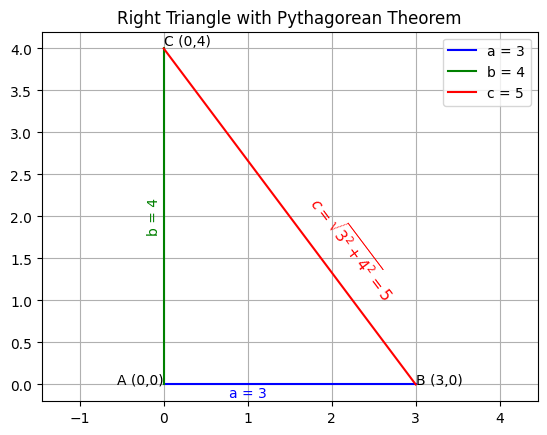

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Triangle vertices
A = np.array([0, 0])
B = np.array([3, 0])  # horizontal leg (a = 3)
C = np.array([0, 4])  # vertical leg (b = 4)

# Plot the triangle sides
plt.plot([A[0], B[0]], [A[1], B[1]], 'b', label='a = 3')
plt.plot([A[0], C[0]], [A[1], C[1]], 'g', label='b = 4')
plt.plot([B[0], C[0]], [B[1], C[1]], 'r', label='c = 5')

# Add point labels
plt.text(*A, 'A (0,0)', fontsize=10, ha='right')
plt.text(*B, 'B (3,0)', fontsize=10, ha='left')
plt.text(*C, 'C (0,4)', fontsize=10, va='bottom')

# Add side length labels
plt.text(1.0, -0.15, 'a = 3', fontsize=10, ha='center', color='blue')     # Bottom side
plt.text(-0.2, 2, 'b = 4', fontsize=10, va='center', rotation=90, color='green')  # Left side
plt.text(1.7, 1, r'$c = \sqrt{3^2 + 4^2} = 5$', fontsize=11, color='red', rotation=-53)


# Formatting
plt.axis('equal')
plt.grid(True)
plt.title("Right Triangle with Pythagorean Theorem")
plt.legend()
plt.show()

We can do the same calculation using coordinates!<br>
1. Take the x-coordinates (first coordinate) for B and C:
$$ 0 - 3 = -3$$
2. Square it:
$$ (-3)^2 = 3^2 = 9 $$
3. Repeat for y-coordinates (second coordinate) for B and C:
$$ 4 - 0 = 4 $$
4. Square it:
$$ 4^2 = 16 $$
5. Take the square root:
$$ \sqrt{(3^2 + 4^2)} = \sqrt{(5^2)} = 5. $$

# Assignment: Compute distances

Calculate the distance between the following points:<br>
1. Pt1=(0, 3). Pt2=(0, 4).
2. Pt1=(1, 0). Pt2=(2, 0).
3. Pt1=(0, 0). Pt2=(3, 4).

In [13]:
import math

print("Problem 1: ", math.sqrt((0-3)**2 + (0-4)**2))

Problem 1:  5.0


# Animation of nearest neighbor classification

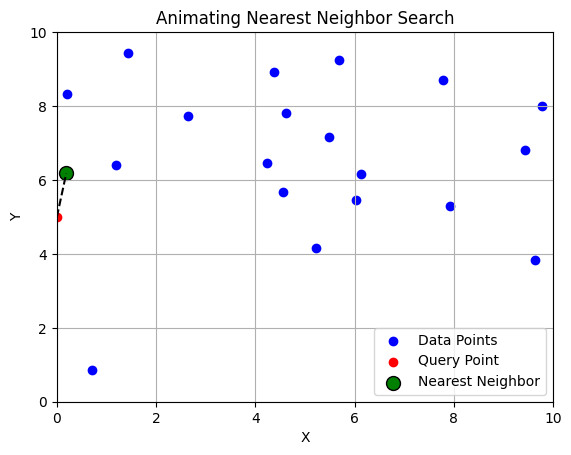

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.spatial import distance
from IPython.display import HTML

# Random data points
np.random.seed(0)
data_points = np.random.rand(20, 2) * 10

# Query path (sweep horizontally with sine wave)
x_vals = np.linspace(0, 10, 100)
y_vals = 5 + np.sin(x_vals)

# Set up the plot
fig, ax = plt.subplots()
sc_data = ax.scatter(data_points[:, 0], data_points[:, 1], color='blue', label='Data Points')
sc_query = ax.scatter([], [], color='red', label='Query Point')
sc_nearest = ax.scatter([], [], color='green', edgecolor='black', s=100, label='Nearest Neighbor')
line, = ax.plot([], [], 'k--')

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_title('Animating Nearest Neighbor Search')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True)
ax.legend()

# Animation update function
def update(frame):
    query = np.array([x_vals[frame], y_vals[frame]])
    distances = [distance.euclidean(query, p) for p in data_points]
    nearest_idx = np.argmin(distances)
    nearest = data_points[nearest_idx]
    sc_query.set_offsets([query])
    sc_nearest.set_offsets([nearest])
    line.set_data([query[0], nearest[0]], [query[1], nearest[1]])
    return sc_query, sc_nearest, line

# Create animation
ani = FuncAnimation(fig, update, frames=len(x_vals), interval=100)


# Display in Colab as HTML5 video
from matplotlib.animation import PillowWriter
from matplotlib import rc
rc('animation', html='html5')

HTML(ani.to_html5_video())

# Identifying cities from the lights

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--2026-06-24 02:43:05--  https://raw.githubusercontent.com/pattichis/AI4All/main/dnb_united_states.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 81746 (80K) [image/jpeg]
Saving to: ‘dnb_united_states.jpg’

dnb_united_states.j 100%[===================>]  79.83K  --.-KB/s    in 0.01s   

2026-06-24 02:43:05 (5.93 MB/s) - ‘dnb_united_states.jpg’ saved [81746/81746]

--2026-06-24 02:43:05--  https://raw.githubusercontent.com/pattichis/AI4All/main/dnb_united_states2.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (

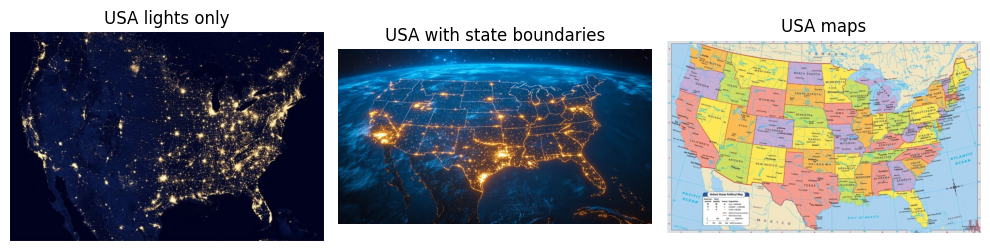

Can you identify the cities?


In [15]:
import matplotlib.pyplot as plt
from PIL import Image

from google.colab import drive
drive.mount('/content/drive')


# 1. Load your images (replace with your file paths or URLs)
# Use -O flag to ensure files are saved with the specified name, overwriting if necessary.
!wget -O dnb_united_states.jpg https://raw.githubusercontent.com/pattichis/AI4All/main/dnb_united_states.jpg
!wget -O dnb_united_states2.jpg https://raw.githubusercontent.com/pattichis/AI4All/main/dnb_united_states2.jpg
!wget -O dnb_united_states3.png https://raw.githubusercontent.com/pattichis/AI4All/main/dnb_united_states3.png


# Open images from the current directory (where wget downloads them).
img1 = Image.open('dnb_united_states.jpg')
img2 = Image.open('dnb_united_states2.jpg')
img3 = Image.open('dnb_united_states3.png')

# Display the images using matplotlib
# 2. Create a figure with 1 row and 2 columns for the two available images
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

# 3. Display each image in its respective subplot
axes[0].imshow(img1)
axes[0].set_title("USA lights only")
axes[0].axis('off')  # Hides the pixel coordinate axes

axes[1].imshow(img2)
axes[1].set_title("USA with state boundaries")
axes[1].axis('off')


axes[2].imshow(img3)
axes[2].set_title("USA maps")
axes[2].axis('off')

# 4. Show the layout
plt.tight_layout()
plt.show()

print("Can you identify the cities?")

# The Digits dataset and K-Nearest neighbor Classification

Goals

1. Recognize the MNIST dataset.
2. Learn how to apply the K-nearest neighbor classifier.

References:<br>
This material is adopted from [Chapter 3 notebook](https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb).

# Setup

This project requires Python 3.7 or above:

In [16]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [17]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Just like in the previous chapter, let's define the default font sizes to make the figures prettier:

In [18]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/classification` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [19]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# MNIST

In [20]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [21]:
print(type(mnist))

<class 'sklearn.utils._bunch.Bunch'>


In [22]:
mnist.keys()  # extra code – we only use data and target in this notebook

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

# Understanding the shape of the mnist dataset

## Reshaping: Flattening images into rows and back into images

Study the code and then answer the questions:
1. What does flatten do? Explain.
2. What is the size of flattened matrix?
3. Why does reshaping D fail?

In [23]:
import numpy as np

A = np.array([[1, 2, 3], [4, 5, 6]])
print("A.shape=", A.shape)
print("A=\n", A)
print(" ")

B = A.flatten()
print("B.shape=", B.shape)
print("B=\n", B)
print(" ")

C = B.reshape(A.shape)
print("C.shape=", C.shape)
print("C=\n", C)

# D = C.reshape(4, 6) # FAILS

A.shape= (2, 3)
A=
 [[1 2 3]
 [4 5 6]]
 
B.shape= (6,)
B=
 [1 2 3 4 5 6]
 
C.shape= (2, 3)
C=
 [[1 2 3]
 [4 5 6]]


# Loading datasets into arrays X, y

Study the code and answer the following:
1. How many images do we have?
2. What does the row size of 784 represent? Explain.
3. Based on y, what do you think the images represent?

In [24]:
X, y = mnist.data, mnist.target

print("X contains one image per row.")
print("Each image is of size 28 rows by 28 pixels.")
print("X=\n", X)
print("X.shape=", X.shape)
print(" ")

print("y contains the label for each image.")
print("y=\n", y)
print("y.shape=", y.shape)

X contains one image per row.
Each image is of size 28 rows by 28 pixels.
X=
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
X.shape= (70000, 784)
 
y contains the label for each image.
y=
 ['5' '0' '4' ... '4' '5' '6']
y.shape= (70000,)


## Visualize the dataset

Study the code and do the following:
1. Do you agree with the label? Explain.
2. Why do we need to reshape in plot_digit?
3. Plot and see the label for different images. Do you agree?

The label is: 5


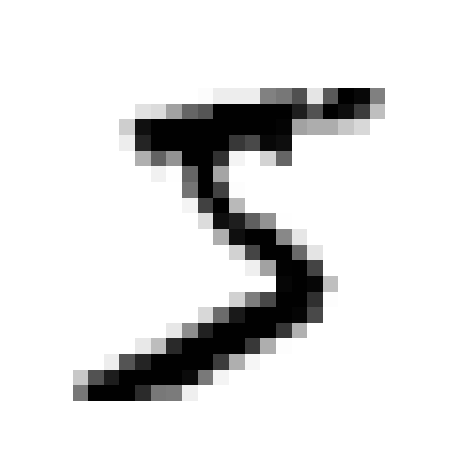

In [25]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
label = y[0]
print("The label is:", label)

plot_digit(some_digit)
save_fig("some_digit_plot")  # extra code
plt.show()

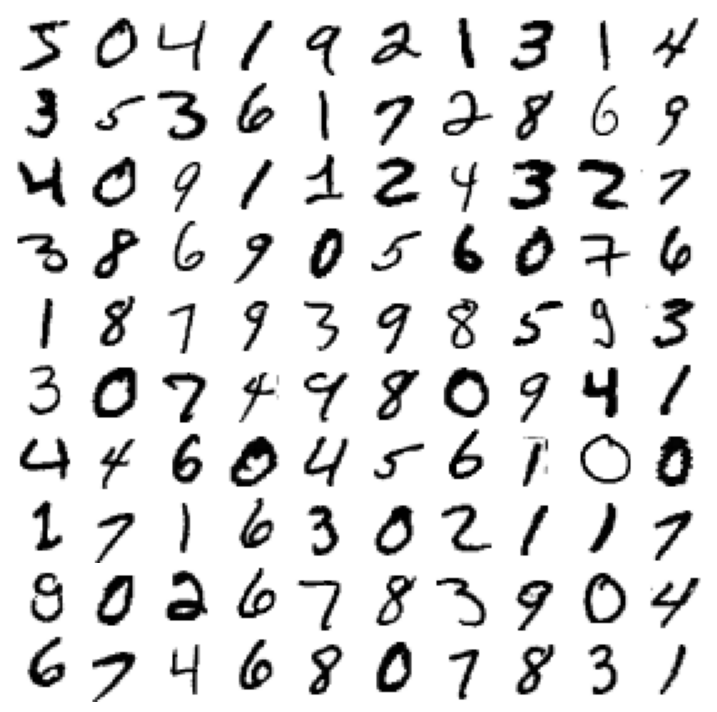

In [26]:
# extra code – this cell generates and saves Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
save_fig("more_digits_plot", tight_layout=False)
plt.show()

# Create training and testing datasets

We train our models on the training dataset.

We test the models on a separate testing dataset.

Why is it importan to not report accuracy on the training dataset?

1. How many images are used for training?
2. How many images are used for testing?
3. What are the indices for the training images?
4. What are the indices for the testing images?

In [27]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

print("X_train.shape=", X_train.shape)
print("y_train.shape=", y_train.shape)
print("X_test.shape=", X_test.shape)
print("y_test.shape=", y_test.shape)

X_train.shape= (60000, 784)
y_train.shape= (60000,)
X_test.shape= (10000, 784)
y_test.shape= (10000,)


# Nearest-neighbor classifier

Recall the KNeighborsClassifier parameters and methods!

In [28]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
help(KNeighborsClassifier)

Help on class KNeighborsClassifier in module sklearn.neighbors._classification:

class KNeighborsClassifier(sklearn.neighbors._base.KNeighborsMixin, sklearn.base.ClassifierMixin, sklearn.neighbors._base.NeighborsBase)
 |  KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)
 |
 |  Classifier implementing the k-nearest neighbors vote.
 |
 |  Read more in the :ref:`User Guide <classification>`.
 |
 |  Parameters
 |  ----------
 |  n_neighbors : int, default=5
 |      Number of neighbors to use by default for :meth:`kneighbors` queries.
 |
 |  weights : {'uniform', 'distance'}, callable or None, default='uniform'
 |      Weight function used in prediction.  Possible values:
 |
 |      - 'uniform' : uniform weights.  All points in each neighborhood
 |        are weighted equally.
 |      - 'distance' : weight points by the inverse of their distance.
 |        in this case, closer neighbors of a q

## Training using fit(.)

Note how long it takes! Write down the time it takes.<br>
Adjust the number of neighbors to a lower value. Does it run faster?

In [29]:
# Adjust the number of neighbors.
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)

KNeighborsClassifier()

## Predicting using predict()

Why is prediction so much faster?<br>
Check the performance on different samples.<br>
Which ones are right?<br>
Which ones are wrong?<br>

In [30]:
y_predict = knn_clf.predict(X_test)
print(y_predict[0])
print(y_test[0])

7
7


## Assess performance using score(.)

Is this accuracy good? Explain.

Go back and vary the number of neighbors to see how it affects performance.<br>

How would you decide the best value?

In [31]:
accuracy = knn_clf.score(X_test, y_test)
print(accuracy)

0.9688
